In [ ]:
import random
import pygad
import networkx as nx
import matplotlib.pyplot as plt
import scipy as sp

TASK 1

In [383]:
def generate_random_graph_txt(filename, num_nodes=10, edge_prob=0.2, max_dist=10):
    with open(filename, "w") as f:
        f.write(f"{num_nodes}\n")

        for u in range(1, num_nodes + 1):
            for v in range(1, num_nodes + 1):
                if u == v:
                    continue  # brez samopovezav

                if random.random() < edge_prob:
                    distance = random.randint(1, max_dist)
                    f.write(f"{u} {v} {distance}\n")

    print(f"Graph saved to {filename}")

In [384]:
# generate_random_graph_txt('graph5.txt', 50)

In [385]:
def read_graph(file_path):
    graph = {}
    with open(file_path, 'r') as f:
        lines = f.readlines()

    num_nodes = int(lines[0].strip())
    for node in range (1, num_nodes + 1):
        graph[node] = []

    for line in lines[1:]:
        parts = line.strip().split()
        if(len(parts) != 3):
            continue

        start = int(parts[0])
        finish = int(parts[1])
        distance = int(parts[2])

        graph[start].append((finish, distance))
    return graph

In [386]:
graph3 = read_graph("graph3.txt")
graph3

graph = read_graph("graph5.txt")

In [387]:
def graph_visualization(graph):
    G = nx.DiGraph()
    for node, value in graph.items():
        for nxt, distance in value:
            G.add_edge(node, nxt, weight=distance)

    pos = nx.spring_layout(G, k=5, iterations=100)
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, width=1, arrowstyle='-|>', arrowsize=7)


    nx.draw_networkx_labels(G, pos, font_size=6, font_color='black')


    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=5)

    plt.axis('off')
    plt.show()


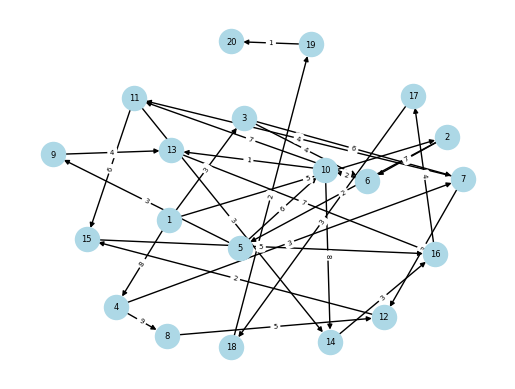

In [388]:
graph_visualization(graph3)

In [389]:
def path_distance(path, graph):
    result = 0

    for i in range(len(path) - 1):
        current_node = path[i]
        next_node = path[i+1]
        neighbors = graph[current_node]

        distance = None
        for(f, d) in neighbors:
            if f == next_node:
                distance = d
                break

        if distance is None:
            return None

        result += distance

    return result

In [390]:
path1 = [1, 3, 4, 5]
path2 = [1, 4, 5]

print("path1:", path_distance(path1, graph3))
print("path2:", path_distance(path2, graph3))

path1: None
path2: None


In [391]:
def generate_path(start, end, graph, max_steps = 100):
    current = start
    path = [current]

    for _ in range(max_steps):
        if current == end:
            return path

        neighbors = graph[current]
        if not neighbors:
            return None

        next_node, _ = random.choice(neighbors)
        path.append(next_node)
        current = next_node

    if current == end:
        return path
    else:
        return None

In [392]:
for i in range(10):
    p = generate_path(1, 20, graph3)
    print(p, " -> distance:", path_distance(p, graph3) if p is not None else None)

[1, 4, 7, 12, 15, 16, 17, 18, 19, 20]  -> distance: 31
[1, 2, 6, 10, 14, 16, 17, 18, 19, 20]  -> distance: 35
[1, 2, 5, 10, 13, 16, 17, 18, 19, 20]  -> distance: 31
[1, 2, 6, 10, 14, 16, 17, 18, 19, 20]  -> distance: 35
[1, 3, 6, 10, 14, 16, 17, 18, 19, 20]  -> distance: 30
[1, 2, 5, 10, 13, 16, 17, 18, 19, 20]  -> distance: 31
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20]  -> distance: 39
[1, 2, 6, 10, 13, 16, 17, 18, 19, 20]  -> distance: 32
[1, 2, 6, 10, 14, 16, 17, 18, 19, 20]  -> distance: 35
[1, 2, 5, 10, 13, 16, 17, 18, 19, 20]  -> distance: 31


In [393]:
def generate_initial_population(start, end , graph, population_size = 50):
    population = []
    attempts = 0

    while (len(population) < population_size and attempts < population_size * 10):
        path = generate_path(start, end, graph)

        if path is not None:
            population.append(path)

        attempts += 1
    return population

In [394]:
population = generate_initial_population(1, 20, graph3, population_size=15)
population

[[1, 3, 7, 12, 15, 16, 17, 18, 19, 20],
 [1, 4, 8, 12, 15, 16, 17, 18, 19, 20],
 [1, 2, 5, 9, 13, 16, 17, 18, 19, 20],
 [1, 4, 8, 12, 15, 16, 17, 18, 19, 20],
 [1, 3, 6, 10, 13, 16, 17, 18, 19, 20],
 [1, 3, 7, 12, 15, 16, 17, 18, 19, 20],
 [1, 2, 5, 10, 14, 16, 17, 18, 19, 20],
 [1, 3, 6, 11, 14, 16, 17, 18, 19, 20],
 [1, 4, 8, 12, 15, 16, 17, 18, 19, 20],
 [1, 4, 7, 11, 14, 16, 17, 18, 19, 20],
 [1, 2, 5, 9, 13, 16, 17, 18, 19, 20],
 [1, 2, 5, 9, 13, 16, 17, 18, 19, 20],
 [1, 4, 8, 12, 15, 16, 17, 18, 19, 20],
 [1, 3, 6, 11, 14, 16, 17, 18, 19, 20],
 [1, 3, 6, 11, 15, 16, 17, 18, 19, 20]]

In [395]:
def fitness(path, graph, start, end):
    if path is None:
        return 1e9

    if path[0] != start or path[-1] != end:
        return 1e9

    dist = path_distance(path, graph)

    if dist is None:
        return 1e9

    return dist

In [396]:
start = 1
end = 20

pop = generate_initial_population(start, end, graph3, population_size=5)

for p in pop:
    print(p, "fitness:", fitness(p, graph3, start, end))


[1, 4, 7, 12, 15, 16, 17, 18, 19, 20] fitness: 31
[1, 4, 8, 12, 15, 16, 17, 18, 19, 20] fitness: 39
[1, 2, 6, 11, 14, 16, 17, 18, 19, 20] fitness: 35
[1, 2, 5, 9, 13, 16, 17, 18, 19, 20] fitness: 31
[1, 2, 5, 10, 14, 16, 17, 18, 19, 20] fitness: 34


In [397]:
def tournament_selection(population, fitnesses, tournament_size = 3):
    indices = random.sample(range(len(population)), tournament_size)
    best_idx = min(indices, key=lambda i: fitnesses[i])

    return population[best_idx]

In [398]:
starts = 1
end = 20
population = generate_initial_population(starts, end, graph, population_size=10)
fitnesses = [fitness(p, graph, starts, end) for p in population]

print("POPULACIJA:")
for p, f in zip(population, fitnesses):
    print(p, "fitness:", f)

print("\nIZBRAN STARŠ:")
parent = tournament_selection(population, fitnesses, tournament_size=3)
print(parent, "fitness:", fitness(parent, graph, start, end))


POPULACIJA:
[1, 34, 12, 30, 31, 40, 44, 37, 33, 43, 18, 40, 1, 14, 29, 21, 2, 37, 9, 28, 24, 20] fitness: 115
[1, 26, 15, 46, 29, 27, 49, 31, 29, 38, 9, 15, 14, 39, 15, 46, 14, 18, 39, 33, 15, 11, 36, 14, 18, 14, 9, 17, 27, 32, 46, 45, 34, 40, 44, 34, 45, 40, 6, 46, 27, 9, 15, 13, 27, 6, 33, 26, 15, 36, 10, 27, 9, 42, 49, 47, 42, 49, 47, 1, 48, 17, 35, 20] fitness: 356
[1, 15, 16, 33, 38, 31, 8, 42, 9, 17, 50, 16, 5, 39, 33, 36, 2, 37, 34, 38, 10, 34, 33, 17, 27, 37, 21, 35, 34, 45, 3, 2, 40, 23, 25, 21, 12, 44, 42, 22, 39, 5, 15, 36, 25, 21, 44, 8, 28, 23, 37, 9, 15, 16, 14, 28, 25, 30, 12, 42, 50, 24, 47, 20] fitness: 375
[1, 34, 50, 16, 5, 11, 33, 43, 33, 17, 35, 20] fitness: 65
[1, 14, 24, 1, 33, 17, 46, 42, 46, 19, 41, 28, 24, 14, 9, 39, 15, 16, 3, 29, 27, 8, 19, 11, 50, 24, 22, 35, 14, 9, 42, 17, 35, 6, 12, 44, 34, 13, 43, 23, 34, 13, 8, 42, 17, 30, 31, 20] fitness: 237
[1, 32, 10, 42, 31, 50, 20] fitness: 37
[1, 48, 27, 34, 33, 36, 14, 22, 10, 47, 2, 26, 35, 23, 37, 33, 17, 38, 

In [399]:
def mutate(path, graph, mutation_probability = 0.1):
    new_path = path[:]

    for i in range(len(new_path) - 1):
        if random.random() < mutation_probability:
            current = new_path[i]
            neighbors = graph[current]

            if not neighbors:
                continue

            next_node, _ = random.choice(neighbors)
            new_path[i + 1] = next_node

    return new_path

In [400]:
p = population[0]
print("Original:", p)

mutated = mutate(p, graph, mutation_probability=0.5)
print("Mutated: ", mutated)

print("Fitness original:", fitness(p, graph, start, end))
print("Fitness mutated: ", fitness(mutated, graph, start, end))


Original: [1, 34, 12, 30, 31, 40, 44, 37, 33, 43, 18, 40, 1, 14, 29, 21, 2, 37, 9, 28, 24, 20]
Mutated:  [1, 15, 12, 30, 31, 40, 44, 37, 4, 43, 30, 40, 44, 14, 29, 6, 8, 37, 9, 28, 23, 20]
Fitness original: 115
Fitness mutated:  1000000000.0


In [401]:
def single_point_crossover(parent1, parent2):
    if len(parent1) < 3 or len(parent2) < 3:
        return parent1[:], parent2[:]

    cut1 = random.randint(1, len(parent1) - 2)
    cut2 = random.randint(1, len(parent2) - 2)

    child1 = parent1[:cut1] + parent2[cut2:]
    child2 = parent2[:cut2] + parent1[cut1:]

    return child1, child2

In [402]:
starts = 1
end = 20

population = generate_initial_population(starts, end, graph, population_size=4)
fitnesses = [fitness(p, graph, starts, end) for p in population]

print("STARŠI:")
for p, f in zip(population, fitnesses):
    print(p, "fitness:", f)

# izberemo 2 starša
parent1 = tournament_selection(population, fitnesses, tournament_size=3)
parent2 = tournament_selection(population, fitnesses, tournament_size=3)

print("\nIZBRAN STARŠ 1:", parent1)
print("IZBRAN STARŠ 2:", parent2)

child1, child2 = single_point_crossover(parent1, parent2)

print("\nOTROCI:")
print("child1:", child1, "fitness:", fitness(child1, graph, start, end))
print("child2:", child2, "fitness:", fitness(child2, graph, start, end))


STARŠI:
[1, 47, 42, 45, 34, 45, 34, 50, 16, 5, 11, 7, 24, 44, 27, 12, 45, 3, 24, 1, 14, 46, 30, 14, 23, 20] fitness: 125
[1, 48, 17, 38, 7, 26, 45, 30, 43, 32, 17, 27, 8, 17, 27, 34, 40, 30, 31, 29, 42, 50, 20] fitness: 137
[1, 9, 15, 9, 28, 25, 21, 5, 42, 31, 50, 17, 38, 23, 39, 13, 30, 24, 20] fitness: 96
[1, 25, 44, 14, 22, 16, 28, 12, 42, 34, 12, 44, 18, 19, 47, 44, 36, 15, 16, 28, 12, 44, 36, 47, 42, 46, 31, 20] fitness: 160

IZBRAN STARŠ 1: [1, 9, 15, 9, 28, 25, 21, 5, 42, 31, 50, 17, 38, 23, 39, 13, 30, 24, 20]
IZBRAN STARŠ 2: [1, 9, 15, 9, 28, 25, 21, 5, 42, 31, 50, 17, 38, 23, 39, 13, 30, 24, 20]

OTROCI:
child1: [1, 9, 15, 9, 28, 25, 21, 5, 42, 31, 50, 42, 31, 50, 17, 38, 23, 39, 13, 30, 24, 20] fitness: 111
child2: [1, 9, 15, 9, 28, 25, 21, 5, 17, 38, 23, 39, 13, 30, 24, 20] fitness: 1000000000.0


In [403]:
def genetic_algorithm(start, end, graph, population_size=50, generations=100, mutation_probability=0.1, tournament_size=3):
    population = generate_initial_population(start, end, graph, population_size)
    best_path = None
    best_fitness = float("inf")

    for gen in range(generations):
        fitnesses = [fitness(p, graph, start, end) for p in population]

        gen_best_idx = min(range(len(population)), key=lambda i: fitnesses[i])
        gen_best_path = population[gen_best_idx]
        gen_best_fitness = fitnesses[gen_best_idx]

        if gen_best_fitness < best_fitness:
            best_fitness = gen_best_fitness
            best_path = gen_best_path

        new_population = []
        new_population.append(best_path)

        while len(new_population) < population_size:
            # izberi starše
            parent1 = tournament_selection(population, fitnesses, tournament_size)
            parent2 = tournament_selection(population, fitnesses, tournament_size)

            # crossover
            child1, child2 = single_point_crossover(parent1, parent2)

            # mutacija
            child1 = mutate(child1, graph, mutation_probability)
            child2 = mutate(child2, graph, mutation_probability)
            new_population.append(child1)

            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return best_path, best_fitness


In [404]:
start = 1
end = 20

best_path, best_fit = genetic_algorithm(start, end, graph, population_size=50, generations=100, mutation_probability=0.1, tournament_size=3)

print("Najdena pot:", best_path)
print("Dolžina poti:", best_fit)


Najdena pot: [1, 20]
Dolžina poti: 9


TASK 2

In [405]:
def generate_path2(targets, graph):
    

   
    current = targets[0]
    path = [current]

        
    success = True
    
    
    for i in range(len(targets)-1):
        current = targets[i]
        nxt = targets[i+1]
        segment = [current]

        future_targets = set(targets[i+2:])
         

    
        while (segment[-1]!= nxt):
            
            possible_nodes =  [node for node, _ in graph.get(segment[-1], []) if node not in segment and node not in future_targets]

            
           
                
            if not possible_nodes:
                success = False
                break
   
            n = random.choice(possible_nodes)
            segment.append(n)

        if not success:
            break


        path.extend(segment[1:])

    if success:
        return path 
    
    return []  

 

In [406]:
for i in range(10):
    p = generate_path2([1, 14, 20], graph3)
    print(p, " -> distance:", path_distance(p, graph3))

[1, 3, 6, 10, 14, 16, 17, 18, 19, 20]  -> distance: 30
[1, 2, 6, 11, 14, 16, 17, 18, 19, 20]  -> distance: 35
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[]  -> distance: 0
[1, 2, 5, 10, 14, 16, 17, 18, 19, 20]  -> distance: 34
[]  -> distance: 0


In [407]:
def generate_initial_population2(targets, graph, population_size = 50):
    population = []
    attempts = 0

    while (len(population) < population_size and attempts < population_size * 10):
        path = generate_path2(targets, graph)

        if path :
            population.append(path)

        attempts += 1
    return population

In [408]:
population2 = generate_initial_population2([1, 3, 19], graph3, population_size=15)
population2

[[1, 3, 6, 10, 14, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 6, 11, 14, 16, 17, 18, 19],
 [1, 3, 7, 11, 15, 16, 17, 18, 19],
 [1, 3, 7, 11, 15, 16, 17, 18, 19],
 [1, 3, 6, 11, 14, 16, 17, 18, 19],
 [1, 3, 7, 11, 15, 16, 17, 18, 19],
 [1, 3, 6, 11, 15, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 7, 12, 15, 16, 17, 18, 19],
 [1, 3, 7, 11, 14, 16, 17, 18, 19],
 [1, 3, 6, 11, 14, 16, 17, 18, 19],
 [1, 3, 6, 11, 14, 16, 17, 18, 19],
 [1, 3, 7, 11, 15, 16, 17, 18, 19],
 [1, 3, 6, 11, 14, 16, 17, 18, 19]]

In [409]:
def make_fitness2(path, graph, targets):
    def fitness2(ga_instance, solution, solution_idx):



        if path is None:
            return 1e-9
    
        it = iter(path)
        if not (all(target in it for target in targets)):
            return 1e-9

        dist = path_distance(path, graph)

        if dist is None:
            return 1e-9

        return 1.0/ (1.0+dist)
    
    return fitness2

In [410]:


for p in population2:
    print(p, "fitness:", make_fitness2(p, graph3, [1, 3, 19]))


[1, 3, 6, 10, 14, 16, 17, 18, 19] fitness: <function make_fitness2.<locals>.fitness2 at 0x000001CFE9184C20>
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: <function make_fitness2.<locals>.fitness2 at 0x000001CFE9184C20>
[1, 3, 6, 11, 14, 16, 17, 18, 19] fitness: <function make_fitness2.<locals>.fitness2 at 0x000001CFE9184C20>
[1, 3, 7, 11, 15, 16, 17, 18, 19] fitness: <function make_fitness2.<locals>.fitness2 at 0x000001CFE9184C20>
[1, 3, 7, 11, 15, 16, 17, 18, 19] fitness: <function make_fitness2.<locals>.fitness2 at 0x000001CFE9184C20>
[1, 3, 6, 11, 14, 16, 17, 18, 19] fitness: <function make_fitness2.<locals>.fitness2 at 0x000001CFE9184C20>
[1, 3, 7, 11, 15, 16, 17, 18, 19] fitness: <function make_fitness2.<locals>.fitness2 at 0x000001CFE9184C20>
[1, 3, 6, 11, 15, 16, 17, 18, 19] fitness: <function make_fitness2.<locals>.fitness2 at 0x000001CFE9184C20>
[1, 3, 7, 12, 15, 16, 17, 18, 19] fitness: <function make_fitness2.<locals>.fitness2 at 0x000001CFE9184C20>
[1, 3, 7, 12, 15, 16, 17, 18

In [411]:
def mutate2(path, graph, targets, mutation_probability = 0.1):
    new_path = path[:]

    for i in range(len(new_path) - 1):
        if path[i+1] in targets:
            continue
        if random.random() < mutation_probability:
            current = new_path[i]
            neighbors = [n for n, _ in graph[current] if n not in targets]


            if not neighbors:
                continue
          
            next_node = random.choice(neighbors)
            new_path[i + 1] = next_node

    return new_path

In [412]:
# p2 = population2[0]
# print("Original:", p2)

# mutated2 = mutate2(p2, graph3,[1, 3, 19], mutation_probability=0.5)
# print("Mutated: ", mutated2)

# print("Fitness original:", fitness2(p2, graph3, [1, 3, 19]))
# print("Fitness mutated: ", fitness2(mutated2, graph3, [1, 3, 19]))


TASK 3

In [413]:
def follows_targets(path, targets):
    # Vrne True, če pot sledi target node-om v zaporedju.
    t_index = 0

    for node in path:
        if t_index < len(targets) and node == targets[t_index]:
            t_index += 1

    return t_index == len(targets)

In [414]:
def generate_path_with_targets(start, end, targets, graph):
    full_path = []
    current = start

    for target in targets + [end]:
        segment = generate_path(current, target, graph)
        if segment is None:
            return None

        if full_path:
            full_path += segment[1:]
        else:
            full_path = segment[:]

        current = target

    return full_path


In [415]:
def generate_multi_agents_path(start_positions, end, graph, targets):
    paths = []
    num_agents = len(start_positions)
    for i in range(num_agents):
        path = generate_path_with_targets(start_positions[i], end, targets, graph)
        if path is None:
            return None
        paths.append(path)   

    return paths

In [416]:
def generate_multi_agents_population(start_positions, end, graph, targets, population_size = 50):
    population = []
    attempts = 0

    while (len(population) < population_size and attempts < population_size * 50):
        path = generate_multi_agents_path(start_positions, end, graph, targets)
        if path is not None:
            population.append(path)   
        attempts += 1
    return population

In [417]:
def move_with_time(path, graph):
    start = path[0]
    path_time = []
    path_time.append(("node", start))

    for i in range(len(path) - 1):
        for (neighbor, distance) in graph[path[i]]:
            if neighbor == path[i + 1]:
                for t in range(distance):
                    path_time.append(("edge", (path[i], path[i + 1])))
                path_time.append(("node", path[i + 1]))
                if i + 1 != len(path) - 1:
                    for t in range (9):
                        path_time.append(("node", path[i + 1]))
                break
            
    return path_time

In [418]:
graph = read_graph("graph1.txt")
path = [1, 3, 4, 5]
print(move_with_time(path, graph))

[('node', 1), ('edge', (1, 3)), ('edge', (1, 3)), ('node', 3), ('node', 3), ('node', 3), ('node', 3), ('node', 3), ('node', 3), ('node', 3), ('node', 3), ('node', 3), ('node', 3), ('edge', (3, 4)), ('node', 4), ('node', 4), ('node', 4), ('node', 4), ('node', 4), ('node', 4), ('node', 4), ('node', 4), ('node', 4), ('node', 4), ('edge', (4, 5)), ('edge', (4, 5)), ('edge', (4, 5)), ('edge', (4, 5)), ('edge', (4, 5)), ('edge', (4, 5)), ('node', 5)]


In [419]:
def expand_agents(paths, graph):
    expanded_paths = []
    max_length = 0
    for path in paths:
        expanded_path = move_with_time(path, graph)
        expanded_paths.append(expanded_path)
        if len(expanded_path) > max_length:
            max_length = len(expanded_path)
    
    for i in range(len(expanded_paths)):
        while len(expanded_paths[i]) < max_length:
            state, value = expanded_paths[i][-1]
            if state == "edge":
                final_node = value[1]
            else:
                final_node = value
            expanded_paths[i].append(("done", final_node))
    
    return expanded_paths

In [420]:
def detect_collision(expanded_paths):
    num_agents = len(expanded_paths)

    for t in range(len(expanded_paths[0])):
        states_at_t = [expanded_paths[i][t] for i in range(num_agents)]
        for i in range(num_agents):
            for j in range(i+1, num_agents):
                state1 = states_at_t[i]
                state2 = states_at_t[j]
                if(state1[0] == "node" and state2[0] == "node" and state1[1] == state2[1]):
                    return True
                
                if(state1[0] == "edge" and state2[0] == "edge"):
                    (u1, v1) = state1[1]
                    (u2, v2) = state2[1]
                    if u1 == u2 and v1 == v2:
                        return True
                    if u1 == v2 and v1 == u2:
                        return True
                    
    return False

In [421]:
def fitness3(paths, graph, start_positions, end, targets):
    for i, path in enumerate(paths):
        if path[0] != start_positions[i]:
            return 1e9
        if path[-1] != end:
            return 1e9
        if not follows_targets(path, targets):
            return 1e9
    
        for j in range(len(path)-1):
                u, v = path[j], path[j+1]
                valid_next = [n for n,_ in graph[u]]
                if v not in valid_next:
                    return 1e9    # punish invalid edge


    expanded = expand_agents(paths, graph)

    if detect_collision(expanded):
        return 1e9

    return len(expanded[0])


In [422]:
def genetic_algorithm3(starts, end, targets, graph, population_size=50, generations=100, mutation_probability=0.1, tournament_size=3):
    population = generate_multi_agents_population(starts, end, graph, targets, population_size)
    best_path = None
    best_fitness = float("inf")

    for gen in range(generations):
        fitnesses = [fitness3(p, graph, starts, end, targets) for p in population]


        gen_best_idx = min(range(len(population)), key=lambda i: fitnesses[i])
        gen_best_path = population[gen_best_idx]
        gen_best_fitness = fitnesses[gen_best_idx]

        if gen_best_fitness < best_fitness:
            best_fitness = gen_best_fitness
            best_path = gen_best_path

        new_population = []
        new_population.append(best_path)

        while len(new_population) < population_size:
            # izberi starše
            parent1 = tournament_selection(population, fitnesses, tournament_size)
            parent2 = tournament_selection(population, fitnesses, tournament_size)

            num_agents = len(parent1)
            # crossover
            child1 = []
            child2 = []
            for i in range(num_agents):
                c1_i, c2_i = single_point_crossover(parent1[i], parent2[i])
                child1.append(c1_i)
                child2.append(c2_i)

            # mutacija
            for i in range(num_agents):
                child1[i] = mutate(child1[i], graph, mutation_probability)
                child2[i] = mutate(child2[i], graph, mutation_probability)

            new_population.append(child1)

            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population

    return best_path, best_fitness

In [427]:
starts = [1, 3]
end = 20
targets = [10]

best, fit = genetic_algorithm3(starts, end, targets, graph3, population_size=20, generations=30)

print("Best solution:", best)
print("Fitness:", fit)

expanded = expand_agents(best, graph3)
print("Collision:", detect_collision(expanded))


Best solution: [[1, 3, 6, 10, 13, 16, 17, 18, 19, 20], [3, 6, 10, 13, 16, 17, 18, 19, 20]]
Fitness: 109
Collision: False


In [ ]:
def print_multi_agent_paths(paths):
    for i, p in enumerate(paths):
        print(f"Agent {i+1}: {' -> '.join(map(str, p))}")


In [ ]:
def draw_paths_on_graph(graph, paths):
    G = nx.DiGraph()
    
    for u, neighbors in graph.items():
        for v, w in neighbors:
            G.add_edge(u, v, weight=w)

    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G, pos, node_size=600, node_color="lightblue")
    nx.draw_networkx_labels(G, pos, font_size=10)

    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=15)

    colors = ["red", "green", "blue", "purple", "orange"]

    for i, path in enumerate(paths):
        edges = [(path[j], path[j+1]) for j in range(len(path)-1)]
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges,
            width=3,
            edge_color=colors[i % len(colors)],
            arrowstyle='-|>',
            arrowsize=20
        )

    plt.axis("off")
    plt.show()


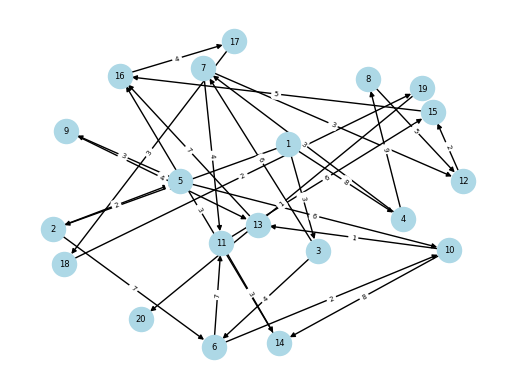

Agent 1: 1 -> 3 -> 6 -> 10 -> 13 -> 16 -> 17 -> 18 -> 19 -> 20
Agent 2: 3 -> 6 -> 10 -> 13 -> 16 -> 17 -> 18 -> 19 -> 20


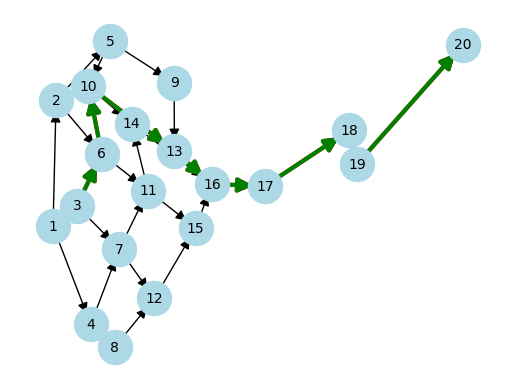

In [428]:
paths = [[1,4,5], [3,4,5]]
graph_visualization(graph3)
print_multi_agent_paths(best)
draw_paths_on_graph(graph3, best)